# Fetch Ligands

This notebook fetch the antibiotics and (ligands with highest
$IC_{50}$ for the given targets) from ChEMBL database using 
`chembl_webresource_client 0.10.9=pyhd8ed1ab_0` python library.

In [2]:
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt
from pubchempy import Compound, get_compounds, download
from chembl_webresource_client.new_client import new_client
from PIL import Image
from rdkit import Chem
from rdkit.Chem import (
    AllChem,
    Mol,
    rdCoordGen,
    rdDepictor,
    PandasTools,
    Draw
)
from rdkit.Chem.Draw import IPythonConsole
from propka import protonate


/var/home/aeersriv/.anaconda3/envs/bioinformatics/lib/python3.14/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [2]:
%matplotlib inline
%config InlineBackend.figure_format="retina"
IPythonConsole.drawOptions.addAtomIndices = False


# Retrieval

In [3]:
antibiotics = [
        "amoxicillin", # penicillins
        "piperacillin",
        "ticarcillin",
        "cefepime", # cephalosporins
        "cefazolin",
        "ceftolozane",
        "ceftriaxone",
        "ceftazidime",
        "aztreonam", # monobactam
        "imipenem", # carbapenems
        "meropenem",
        "doripenem",
        "vancomycin", # glycopeptide
        "minocycline", # tetracyclines
        "tigecycline",
        "doxycycline",
        "tetracycline",
        "Chlortetracycline",
        "azithromycin", # macrolides
        "erythromycin",
        "clarithromycin",
        "chloramphenicol", # chlorampenicol
        "linezolid", # oxazolidinones
        "amikacin", # aminoglycosides
        "tobramycin",
        "streptomycin",
        "kanamycin",
        "trimethoprim", # trimethoprim
        "sulfamethoxazole", # sulfamethoxazole
        "ciprofloxacin", # quinolones
        "levofloxacin",
        "Moxifloxacin"
    ]


In [102]:
ab_cid: dict[str, dict] = {}

for ab in antibiotics:
    res = get_compounds(ab, "name", record_type="3d")
    if len(res) == 0:
        res = get_compounds(ab, "name")
    cid = res[0].cid
    ab_cid[ab] = Compound.from_cid(cid).to_dict(
            [
                "cid",
                "smiles",
                "inchi",
                "coordinate_type",
                "xlogp",
                "tpsa",
                "h_bond_donor_count",
                "h_bond_acceptor_count",
                "rotatable_bond_count",
                "cactvs_fingerprint"
            ]
        )
    download("sdf", f"../data/sdf/{cid}.sdf", cid, overwrite=True)


In [103]:
compound_query = pd.DataFrame(ab_cid)
compound_query


,amoxicillin,piperacillin,ticarcillin,cefepime,cefazolin,ceftolozane,ceftriaxone,ceftazidime,aztreonam,imipenem,...,linezolid,amikacin,tobramycin,streptomycin,kanamycin,trimethoprim,sulfamethoxazole,ciprofloxacin,levofloxacin,Moxifloxacin
cid,33613,43672,36921,5479537,33255,53234134,5479530,5481173,5742832,104838,...,441401,37768,36294,19649,6032,5578,5329,2764,149096,152946
smiles,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,CCN1CCN(C(=O)C1=O)C(=O)N[C@H](C2=CC=CC=C2)C(=O...,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,C[N+]1(CCCC1)CC2=C(N3[C@@H]([C@@H](C3=O)NC(=O)...,CC1=NN=C(S1)SCC2=C(N3[C@@H]([C@@H](C3=O)NC(=O)...,CC(C)(C(=O)O)O/N=C(/C1=NSC(=N1)N)\C(=O)N[C@H]2...,CN1C(=NC(=O)C(=O)N1)SCC2=C(N3[C@@H]([C@@H](C3=...,CC(C)(C(=O)O)O/N=C(/C1=CSC(=N1)N)\C(=O)N[C@H]2...,C[C@H]1[C@@H](C(=O)N1S(=O)(=O)O)NC(=O)/C(=N\OC...,C[C@H]([C@@H]1[C@H]2CC(=C(N2C1=O)C(=O)O)SCCN=CN)O,...,CC(=O)NC[C@H]1CN(C(=O)O1)C2=CC(=C(C=C2)N3CCOCC3)F,C1[C@@H]([C@H]([C@@H]([C@H]([C@@H]1NC(=O)[C@H]...,C1[C@@H]([C@H]([C@@H]([C@H]([C@@H]1N)O[C@@H]2[...,C[C@H]1[C@@]([C@H]([C@@H](O1)O[C@@H]2[C@H]([C@...,C1[C@H]([C@@H]([C@H]([C@@H]([C@H]1N)O[C@@H]2[C...,COC1=CC(=CC(=C1OC)OC)CC2=CN=C(N=C2N)N,CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N,C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O,C[C@H]1COC2=C3N1C=C(C(=O)C3=CC(=C2N4CCN(CC4)C)...,COC1=C2C(=CC(=C1N3C[C@@H]4CCCN[C@@H]4C3)F)C(=O...
inchi,InChI=1S/C16H19N3O5S/c1-16(2)11(15(23)24)19-13...,InChI=1S/C23H27N5O7S/c1-4-26-10-11-27(19(32)18...,InChI=1S/C15H16N2O6S2/c1-15(2)9(14(22)23)17-11...,InChI=1S/C19H24N6O5S2/c1-25(5-3-4-6-25)7-10-8-...,InChI=1S/C14H14N8O4S3/c1-6-17-18-14(29-6)28-4-...,"InChI=1S/C23H30N12O8S2/c1-23(2,20(40)41)43-31-...",InChI=1S/C18H18N8O7S3/c1-25-18(22-12(28)13(29)...,"InChI=1S/C22H22N6O7S2/c1-22(2,20(33)34)35-26-1...","InChI=1S/C13H17N5O8S2/c1-5-7(10(20)18(5)28(23,...",InChI=1S/C12H17N3O4S/c1-6(16)9-7-4-8(20-3-2-14...,...,InChI=1S/C16H20FN3O4/c1-11(21)18-9-13-10-20(16...,InChI=1S/C22H43N5O13/c23-2-1-8(29)20(36)27-7-3...,InChI=1S/C18H37N5O9/c19-3-9-8(25)2-7(22)17(29-...,"InChI=1S/C21H39N7O12/c1-5-21(36,4-30)16(40-17-...",InChI=1S/C18H36N4O11/c19-2-6-10(25)12(27)13(28...,InChI=1S/C14H18N4O3/c1-19-10-5-8(6-11(20-2)12(...,InChI=1S/C10H11N3O3S/c1-7-6-10(12-16-7)13-17(1...,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,InChI=1S/C18H20FN3O4/c1-10-9-26-17-14-11(16(23...,InChI=1S/C21H24FN3O4/c1-29-20-17-13(19(26)14(2...
coordinate_type,2d,2d,2d,2d,2d,2d,2d,2d,2d,2d,...,2d,2d,2d,2d,2d,2d,2d,2d,2d,2d
xlogp,-2,0.5,0.8,-0.1,-0.4,-3.2,-1.3,0.4,0.3,-0.7,...,0.7,-7.9,-6.2,-8,-6.9,0.9,0.9,-1.1,-0.4,0.6
tpsa,158,182,178,204,235,356,288,245,238,142,...,71.1,332,268,336,283,106,107,72.9,73.3,82.1
h_bond_donor_count,4,3,3,2,2,7,4,3,4,3,...,1,13,10,12,11,2,2,2,1,2
h_bond_acceptor_count,7,8,8,10,12,16,13,12,12,6,...,6,17,14,15,15,7,6,7,8,8
rotatable_bond_count,4,6,5,6,7,11,8,8,7,6,...,4,10,6,9,6,5,3,3,2,4
cactvs_fingerprint,1110000001111011001110000000000001000000000000...,1110000001111011101110000000000001000000000000...,1110000001110011001110000000000001100000000000...,1110000001111011101110000000000001100000000000...,1100000001110011111110000000000001100000000000...,1110000001111011111111000000000001100000000000...,1110000001111011111110000000000001100000000000...,1110000001111011101110000000000001100000000000...,1110000001110011101111000000000001100000000000...,1110000001110011001110000000000001000000000000...,...,1110000001111011001110010000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1110000001110011101100000000000000000000000000...,1100000001110011001100000000000001000000000000...,1110000001111011001100010000000000000000000000...,1110000001111011001110010000000000000000000000...,1110000001111011001110010000000000000000000000...


In [104]:
compound_query.to_csv("../data/output/antibiotics_pubchem_query.csv")


# Analysis

In [14]:
dataset = pd.read_csv(
        "../data/output/antibiotics_pubchem_query.csv", index_col=0
    )


In [15]:
dataset.head()


,amoxicillin,piperacillin,ticarcillin,cefepime,cefazolin,ceftolozane,ceftriaxone,ceftazidime,aztreonam,imipenem,...,linezolid,amikacin,tobramycin,streptomycin,kanamycin,trimethoprim,sulfamethoxazole,ciprofloxacin,levofloxacin,Moxifloxacin
cid,33613,43672,36921,5479537,33255,53234134,5479530,5481173,5742832,104838,...,441401,37768,36294,19649,6032,5578,5329,2764,149096,152946
smiles,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,CCN1CCN(C(=O)C1=O)C(=O)N[C@H](C2=CC=CC=C2)C(=O...,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,C[N+]1(CCCC1)CC2=C(N3[C@@H]([C@@H](C3=O)NC(=O)...,CC1=NN=C(S1)SCC2=C(N3[C@@H]([C@@H](C3=O)NC(=O)...,CC(C)(C(=O)O)O/N=C(/C1=NSC(=N1)N)\C(=O)N[C@H]2...,CN1C(=NC(=O)C(=O)N1)SCC2=C(N3[C@@H]([C@@H](C3=...,CC(C)(C(=O)O)O/N=C(/C1=CSC(=N1)N)\C(=O)N[C@H]2...,C[C@H]1[C@@H](C(=O)N1S(=O)(=O)O)NC(=O)/C(=N\OC...,C[C@H]([C@@H]1[C@H]2CC(=C(N2C1=O)C(=O)O)SCCN=CN)O,...,CC(=O)NC[C@H]1CN(C(=O)O1)C2=CC(=C(C=C2)N3CCOCC3)F,C1[C@@H]([C@H]([C@@H]([C@H]([C@@H]1NC(=O)[C@H]...,C1[C@@H]([C@H]([C@@H]([C@H]([C@@H]1N)O[C@@H]2[...,C[C@H]1[C@@]([C@H]([C@@H](O1)O[C@@H]2[C@H]([C@...,C1[C@H]([C@@H]([C@H]([C@@H]([C@H]1N)O[C@@H]2[C...,COC1=CC(=CC(=C1OC)OC)CC2=CN=C(N=C2N)N,CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N,C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O,C[C@H]1COC2=C3N1C=C(C(=O)C3=CC(=C2N4CCN(CC4)C)...,COC1=C2C(=CC(=C1N3C[C@@H]4CCCN[C@@H]4C3)F)C(=O...
inchi,InChI=1S/C16H19N3O5S/c1-16(2)11(15(23)24)19-13...,InChI=1S/C23H27N5O7S/c1-4-26-10-11-27(19(32)18...,InChI=1S/C15H16N2O6S2/c1-15(2)9(14(22)23)17-11...,InChI=1S/C19H24N6O5S2/c1-25(5-3-4-6-25)7-10-8-...,InChI=1S/C14H14N8O4S3/c1-6-17-18-14(29-6)28-4-...,"InChI=1S/C23H30N12O8S2/c1-23(2,20(40)41)43-31-...",InChI=1S/C18H18N8O7S3/c1-25-18(22-12(28)13(29)...,"InChI=1S/C22H22N6O7S2/c1-22(2,20(33)34)35-26-1...","InChI=1S/C13H17N5O8S2/c1-5-7(10(20)18(5)28(23,...",InChI=1S/C12H17N3O4S/c1-6(16)9-7-4-8(20-3-2-14...,...,InChI=1S/C16H20FN3O4/c1-11(21)18-9-13-10-20(16...,InChI=1S/C22H43N5O13/c23-2-1-8(29)20(36)27-7-3...,InChI=1S/C18H37N5O9/c19-3-9-8(25)2-7(22)17(29-...,"InChI=1S/C21H39N7O12/c1-5-21(36,4-30)16(40-17-...",InChI=1S/C18H36N4O11/c19-2-6-10(25)12(27)13(28...,InChI=1S/C14H18N4O3/c1-19-10-5-8(6-11(20-2)12(...,InChI=1S/C10H11N3O3S/c1-7-6-10(12-16-7)13-17(1...,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,InChI=1S/C18H20FN3O4/c1-10-9-26-17-14-11(16(23...,InChI=1S/C21H24FN3O4/c1-29-20-17-13(19(26)14(2...
coordinate_type,2d,2d,2d,2d,2d,2d,2d,2d,2d,2d,...,2d,2d,2d,2d,2d,2d,2d,2d,2d,2d
xlogp,-2,0.5,0.8,-0.1,-0.4,-3.2,-1.3,0.4,0.3,-0.7,...,0.7,-7.9,-6.2,-8,-6.9,0.9,0.9,-1.1,-0.4,0.6


In [17]:
struct = []
for compound in dataset:
    struct.append(Chem.MolFromInchi(dataset[compound]["inchi"]))


In [20]:
struct


In [21]:
dataset.loc["struct"] = struct
dataset.tail()


,amoxicillin,piperacillin,ticarcillin,cefepime,cefazolin,ceftolozane,ceftriaxone,ceftazidime,aztreonam,imipenem,...,linezolid,amikacin,tobramycin,streptomycin,kanamycin,trimethoprim,sulfamethoxazole,ciprofloxacin,levofloxacin,Moxifloxacin
h_bond_donor_count,4,3,3,2,2,7,4,3,4,3,...,1,13,10,12,11,2,2,2,1,2
h_bond_acceptor_count,7,8,8,10,12,16,13,12,12,6,...,6,17,14,15,15,7,6,7,8,8
rotatable_bond_count,4,6,5,6,7,11,8,8,7,6,...,4,10,6,9,6,5,3,3,2,4
cactvs_fingerprint,1110000001111011001110000000000001000000000000...,1110000001111011101110000000000001000000000000...,1110000001110011001110000000000001100000000000...,1110000001111011101110000000000001100000000000...,1100000001110011111110000000000001100000000000...,1110000001111011111111000000000001100000000000...,1110000001111011111110000000000001100000000000...,1110000001111011101110000000000001100000000000...,1110000001110011101111000000000001100000000000...,1110000001110011001110000000000001000000000000...,...,1110000001111011001110010000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1110000001110011101100000000000000000000000000...,1100000001110011001100000000000001000000000000...,1110000001111011001100010000000000000000000000...,1110000001111011001110010000000000000000000000...,1110000001111011001110010000000000000000000000...
struct,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f9460>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f9070>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57fa810>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57fa7a0>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57fa490>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f9d90>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f9e00>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f92a0>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f9230>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f91c0>,...,<rdkit.Chem.rdchem.Mol object at 0x7f83d57faf80>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f8820>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f8dd0>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57fb060>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f87b0>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f8660>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f8a50>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f85f0>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f84a0>,<rdkit.Chem.rdchem.Mol object at 0x7f83d57f83c0>


In [ ]:
antibiotics_arr = [
        [
            "amoxicillin", # penicillins
            "piperacillin",
            "ticarcillin"
        ], [
            "cefepime", # cephalosporins
            "cefazolin",
            "ceftolozane",
            "ceftriaxone",
            "ceftazidime",
        ], [
            "aztreonam" # monobactam
        ], [
            "imipenem", # carbapenems
            "meropenem",
            "doripenem"
        ], [
            "vancomycin" # glycopeptide
        ], [
            "minocycline", # tetracyclines
            "tigecycline",
            "doxycycline",
            "tetracycline",
            "Chlortetracycline"
        ], [
            "azithromycin", # macrolides
            "erythromycin",
            "clarithromycin"
        ], [
            "chloramphenicol" # chlorampenicol
        ], [
            "linezolid" # oxazolidinones
        ], [
            "amikacin", # aminoglycosides
            "tobramycin",
            "streptomycin",
            "kanamycin"
        ], [
            "trimethoprim" # trimethoprim
        ], [
            "sulfamethoxazole" # sulfamethoxazole
        ], [
            "ciprofloxacin", # quinolones
            "levofloxacin",
            "Moxifloxacin"
        ]
    ]


[[<rdkit.Chem.rdchem.Mol at 0x7f83d57f9460>,

In [43]:
legends_arr: list[str] = []
struct_arr: list[Mol] = []

for ab_arr in antibiotics_arr:
    struct_subarr: list[Mol] = []
    legends_subarr: list[str] = []
    for ab in ab_arr:
        struct_subarr.append(dataset[ab]["struct"])
        legends_subarr.append(ab.title())

    struct_arr.append(struct_subarr)
    legends_arr.append(legends_subarr)


In [48]:
struct_arr, legends_arr


([[<rdkit.Chem.rdchem.Mol at 0x7f83d57f9460>,
 [['Amoxicillin', 'Piperacillin', 'Ticarcillin'],
  ['Cefepime', 'Cefazolin', 'Ceftolozane', 'Ceftriaxone', 'Ceftazidime'],
  ['Aztreonam'],
  ['Imipenem', 'Meropenem', 'Doripenem'],
  ['Vancomycin'],
  ['Minocycline',
   'Tigecycline',
   'Doxycycline',
   'Tetracycline',
   'Chlortetracycline'],
  ['Azithromycin', 'Erythromycin', 'Clarithromycin'],
  ['Chloramphenicol'],
  ['Linezolid'],
  ['Amikacin', 'Tobramycin', 'Streptomycin', 'Kanamycin'],
  ['Trimethoprim'],
  ['Sulfamethoxazole'],
  ['Ciprofloxacin', 'Levofloxacin', 'Moxifloxacin']])

/var/home/aeersriv/.anaconda3/envs/bioinformatics/lib/python3.14/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


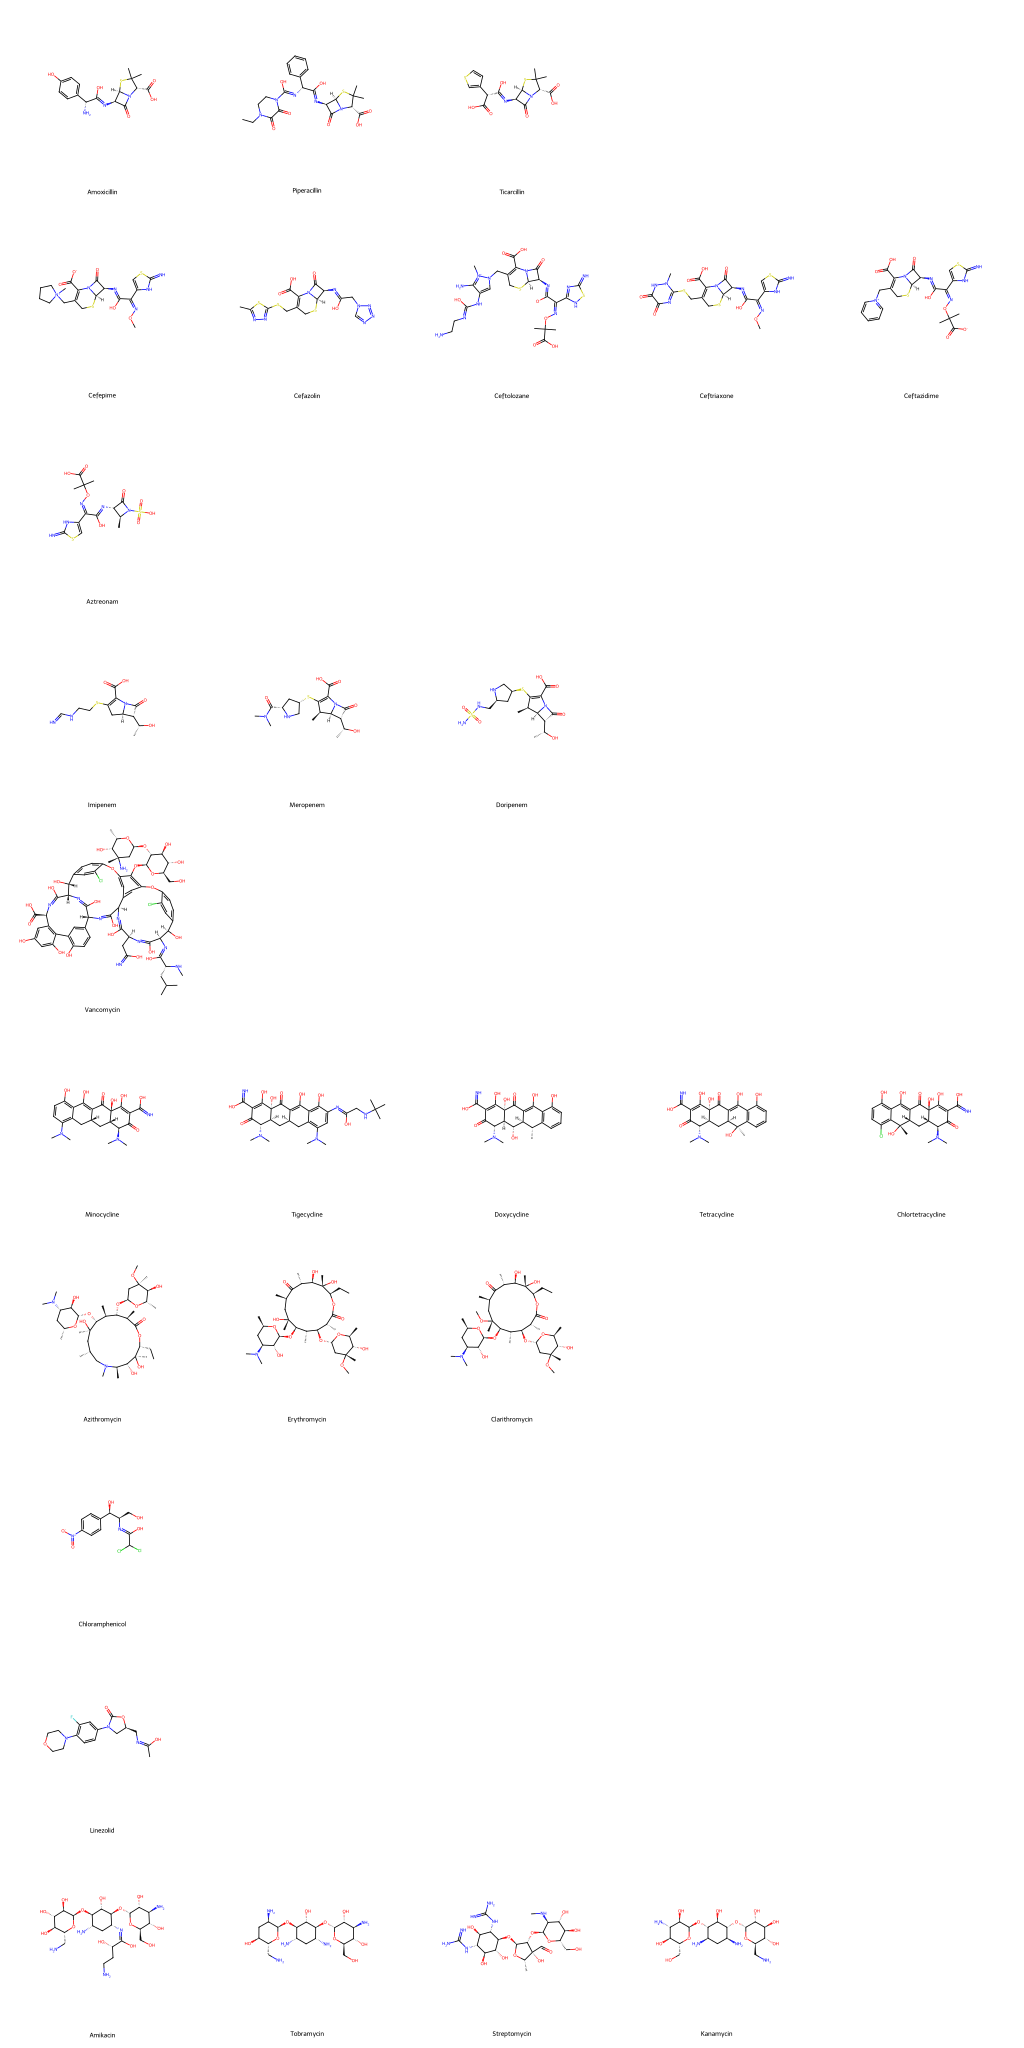

In [51]:
img = Draw.MolsMatrixToGridImage(
    molsMatrix=struct_arr,
    legendsMatrix=legends_arr,
    subImgSize=(512, 512),
    useSVG=True,

)

# with open(
#         "../output/antibiotics_arr.svg", "w", encoding="utf8"
#     ) as out:
    # out.write(img.data)
img
